<a href="https://colab.research.google.com/github/mdonbruce/AspNetDocs/blob/master/Module5_Assignment_CODELAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Google Colab Codelab – Module 5 Model Evaluation
## Guided Walkthrough: Classification + Regression Metrics

Run each cell in order and capture screenshots of outputs and plots.


## Step 0 — Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

plt.rcParams['figure.figsize'] = (7,4)


---
## Part A — Classification (Logistic Regression)


### Step 1 — Load dataset

In [3]:
df = pd.read_csv('classification_metrics_large.csv')
print('shape:', df.shape)
df.head()

shape: (60000, 20)


,case_id,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11,feat_12,feat_13,feat_14,feat_15,feat_16,feat_17,feat_18,label
0,1,-0.906708,1.511773,0.998741,-0.200713,-2.785514,1.590835,-0.856109,2.406448,-1.019194,-0.509689,1.140887,-0.710171,2.432862,6.771631,-1.386070,1.121501,-0.510327,-2.882688,0
1,2,0.896504,-1.475718,-0.755905,-0.362356,2.203082,-0.861743,-1.869468,0.577992,-2.204351,0.353367,-5.238456,-0.639637,-0.542944,0.429876,1.074554,1.589087,3.201093,-2.171578,0
2,3,-0.906677,-1.576150,-8.404254,0.884796,2.868565,-3.980481,0.530123,-3.150214,0.099882,2.439246,3.392292,-1.232640,-7.359997,-1.541453,1.381373,2.890381,-1.175753,-4.297745,0
3,4,0.844525,1.971633,3.226369,-0.363605,-2.012855,1.422625,2.246727,0.080248,-1.780205,-0.552970,1.724596,1.440787,-1.456372,3.954762,1.130623,3.671572,1.654060,-1.839708,0
4,5,-0.445633,-2.859422,-3.754321,1.294272,-2.556395,-3.130666,-1.339987,-1.571084,0.717391,3.802030,1.664713,0.566021,-1.834241,1.337763,-2.571626,2.594857,-0.996254,0.893459,0


### Step 2 — Split (use stratify)

In [4]:
X = df.drop(columns=['case_id','label'])
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print('train:', X_train.shape, 'test:', X_test.shape)

train: (45000, 18) test: (15000, 18)


### Step 3 — Train model + predictions

In [5]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print('trained')

trained


### Step 4 — Metrics

In [6]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy={acc:.3f} Precision={prec:.3f} Recall={rec:.3f} F1={f1:.3f}')

Accuracy=0.902 Precision=0.779 Recall=0.522 F1=0.625


### Step 5 — Confusion Matrix

[[12299   349]
 [ 1125  1227]]


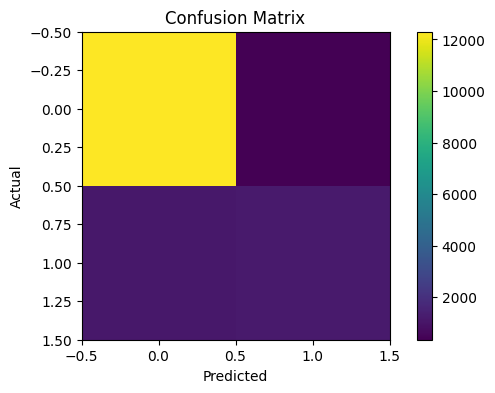

In [7]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
plt.show()

### Step 6 — ROC Curve + AUC

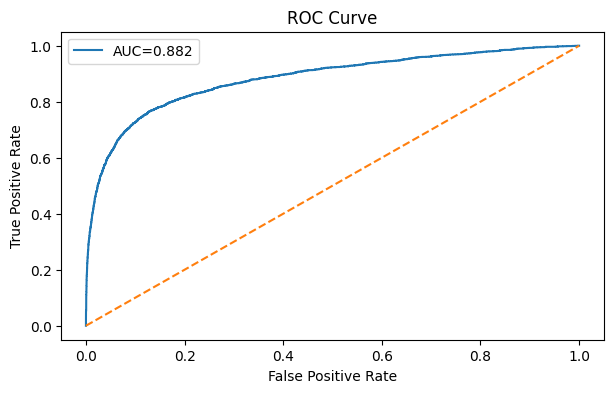

In [8]:
probs = clf.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, probs)
fpr, tpr, _ = roc_curve(y_test, probs)
plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### Step 7 — Threshold Tuning

In [9]:
for thr in [0.50, 0.30, 0.20]:
    y_pred_thr = (probs >= thr).astype(int)
    p = precision_score(y_test, y_pred_thr)
    r = recall_score(y_test, y_pred_thr)
    print(f'Threshold={thr:.2f} | Precision={p:.3f} | Recall={r:.3f}')

Threshold=0.50 | Precision=0.779 | Recall=0.522
Threshold=0.30 | Precision=0.629 | Recall=0.685
Threshold=0.20 | Precision=0.517 | Recall=0.770


---
## Part B — Regression (Linear Regression)


### Step 8 — Load dataset

In [10]:
dfh = pd.read_csv('housing_regression_large.csv')
print('shape:', dfh.shape)
dfh.head()

shape: (60000, 6)


,sqft,bedrooms,age,crime_rate,school_score,price
0,2073.0,4,14.6,1.22,8.5,491890.0
1,1724.0,5,28.2,7.40,7.8,470910.0
2,2156.0,3,15.1,0.03,6.9,549301.0
3,2638.0,1,23.1,0.69,6.7,557409.0
4,1671.0,2,28.4,1.38,5.4,361086.0


### Step 9 — Train/test split + train model

In [11]:
Xr = dfh.drop(columns=['price'])
yr = dfh['price']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    Xr, yr, test_size=0.25, random_state=42
)
reg = LinearRegression()
reg.fit(X_train_r, y_train_r)
preds = reg.predict(X_test_r)
print('trained')

trained


### Step 10 — Metrics

In [13]:
mae = mean_absolute_error(y_test_r, preds)
rmse = np.sqrt(mean_squared_error(y_test_r, preds))
r2 = r2_score(y_test_r, preds)
print(f'MAE={mae:.2f} RMSE={rmse:.2f} R2={r2:.3f}')

MAE=28051.87 RMSE=35025.56 R2=0.886


### Step 11 — Residual Plot

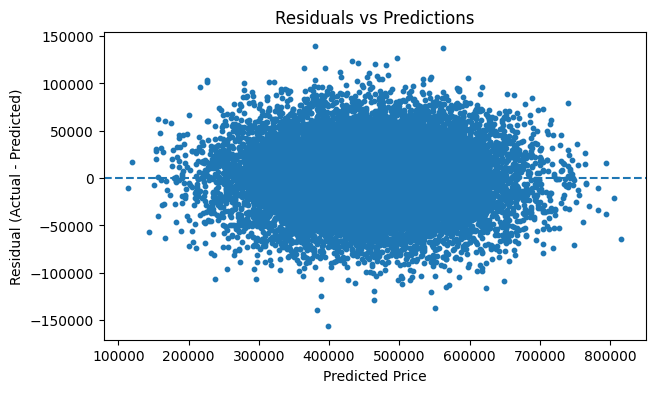

In [14]:
resid = y_test_r - preds
plt.scatter(preds, resid, s=10)
plt.axhline(0, linestyle='--')
plt.title('Residuals vs Predictions')
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.show()

---
## Final Checkpoint
Use these questions in your written report:
1) Which metric mattered most and why?
2) How did thresholds shift precision vs recall?
3) Interpret MAE/RMSE in dollars.
4) What does the residual plot suggest?
5) Recommend improvements.
